In [1]:
from hossam import load_data
from helpers import *
import os                       # 파일 및 디렉토리 경로 처리
import numpy as np              # 배열 연산
from pandas import DataFrame    # 결과를 표로 정리
import pandas as pd

# 데이터셋을 학습용과 테스트용으로 분할
from sklearn.model_selection import train_test_split

# GridSearchCV 객체를 분할하는 함수
from helpers.my_ml import _unwrap_estimator

import shap

from matplotlib import pyplot as plt

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.25

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.25, 최신 버전: 0.5.33)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



## 3. 데이터 불러오기 + 범주형 타입 변환

In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("streeteasy_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["bed_bath_constraint", "building_era", "cluster_name", "amenity_level"])

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   size_sqft            3512 non-null   float64 
 1   min_to_subway        3512 non-null   float64 
 2   building_era         3512 non-null   category
 3   relative_floor       3512 non-null   float64 
 4   relative_size        3512 non-null   float64 
 5   bed_bath_constraint  3512 non-null   category
 6   cluster_name         3512 non-null   category
 7   amenity_level        3512 non-null   category
 8   rent                 3512 non-null   float64 
dtypes: category(4), float64(5)
memory usage: 151.1 KB


## 4. 독립변수와 종속변수 분리 후 훈련·검증 데이터 분할

In [3]:
# 독립변수 분리
feature = df.drop(columns=["rent"])

# 종속변수 분리
target = df["rent"]

# 훈련, 검증 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(feature, target, 
                                    test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2809, 8), (703, 8), (2809,), (703,))

## 4. 모델 폴더 지정

In [4]:
project_name = "streeteasy"

# 튜닝 완료 모델이 저장되어 있는 폴더
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

# shap 분석 결과가 저장될 폴더
shap_dir = f"{project_name}/shap"

if not os.path.exists(shap_dir):
    os.makedirs(shap_dir)

## 1. 대상 모델 로드하기

In [5]:
estimator = my_ml.load_model(f"{project_name}/importance/xgb_imp_tuned.pkl")
estimator

c:\Users\dltoc\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [23:36:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(n_jobs=-1,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('vif_selector',
                                                                                          VIFSelector())]),
                                                                         ['size_sqft',
                                                                          'relative_floor']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown

## 2. 최종 모델 추출

In [6]:
model, pre, *_ = _unwrap_estimator(estimator)
model_class = type(model).__name__
print(f"모델 클래스명: {model_class}")

모델 클래스명: XGBRegressor


## 3. 전처리 재현하기

In [7]:
x_df = pre.transform(x_train).copy()
x_df.head()

,size_sqft,relative_floor,building_era_0,building_era_1,building_era_2,building_era_3,cluster_name_0,cluster_name_1,cluster_name_2,cluster_name_3,amenity_level_0,amenity_level_1,amenity_level_2,bed_bath_constraint_0,bed_bath_constraint_1
15,6.802,0.579,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
2274,7.090,0.569,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000
2339,6.500,0.981,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
400,7.313,0.929,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000
2910,6.534,0.636,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000


## 4. TreeExplainer 생성
- 데이터를 넘기지 않는다

In [8]:
explainer = shap.TreeExplainer(model)
explainer

## 5. SHAP계산

In [9]:
%%time

raw = explainer.shap_values(x_df)
expected_value = explainer.expected_value

print(f"SHAP 값 배열 모양: {np.asarray(raw).shape}")
print(f"base value: {expected_value}")

DataFrame(raw, columns=x_df.columns, index=x_df.index).head()

SHAP 값 배열 모양: (2809, 15)
base value: 8.404949188232422
CPU times: total: 3.84 s
Wall time: 350 ms


,size_sqft,relative_floor,building_era_0,building_era_1,building_era_2,building_era_3,cluster_name_0,cluster_name_1,cluster_name_2,cluster_name_3,amenity_level_0,amenity_level_1,amenity_level_2,bed_bath_constraint_0,bed_bath_constraint_1
15,-0.082,0.049,0.003,-0.044,-0.002,-0.034,0.005,0.004,0.011,0.000,-0.002,0.001,-0.005,0.006,0.000
2274,0.213,0.191,-0.000,-0.026,0.000,-0.040,-0.012,0.005,0.009,-0.000,-0.003,-0.000,0.011,0.008,0.000
2339,-0.250,0.009,0.002,0.043,-0.002,0.005,0.001,-0.004,0.017,0.000,-0.003,0.004,0.001,0.014,0.000
400,0.395,0.336,-0.001,-0.022,0.001,-0.015,-0.007,0.052,0.016,-0.000,-0.005,0.001,0.027,0.032,0.000
2910,-0.213,0.144,0.001,0.046,-0.002,0.005,0.002,-0.002,0.009,0.001,-0.001,0.003,0.003,0.013,0.000


# 05. 요약표 작성
## SHAP값 배열 정리
- explainer가 돌려준 것은 SHAP값 배열 하나다.

In [10]:
arr = np.asarray(raw)

if arr.ndim == 3:
    pass
else:
    shap_2d = arr.astype(float)
    base_value = float(np.ravel(expected_value)[0])

print(f"설명 대상 SHAP 배열: {shap_2d.shape}")
print(f"base value: {base_value}")

설명 대상 SHAP 배열: (2809, 15)
base value: 8.404949188232422


## 2. 가산성으로 모델 출력 복원
- SHAP 값의 단위는 모델과 explainer 조합에 따라 달라진다.
- 그래서 가산성을 거꾸로 이용해 단위를 되짚는다.

In [11]:
preds = shap_2d.sum(axis=1) + base_value
print(f"복원한 출력 (앞 5개): {preds[:5]}")

복원한 출력 (앞 5개): [8.3155216  8.76089265 8.24180323 9.21332197 8.41443691]


## 3. 예측값과 대조
- 복원한 값이 model.predict와 사실상 같으면 y단위다.

In [12]:
# y 단위 예측값과 맞아떨어지는지 확인한다
y_hat = np.asarray(model.predict(x_df), dtype=float).ravel()
scale = float(np.abs(y_hat).mean()) + 1e-9      # 오차 허용치의 기준 크기
error = float(np.abs(preds - y_hat).mean())

print(f"예측값과의 평균 오차: {error}")
print(f"허용치: {scale * 1e-3}")

if error < scale * 1e-3:    # 예측값과 사실상 일치하면
    output_space = '예측값(y 단위)'
else:                       # 어긋나면 단위를 특정할 수 없다
    output_space = '알 수 없음'

print(f"SHAP 값의 단위: {output_space}")

예측값과의 평균 오차: 5.929673570916602e-06
허용치: 0.008404950738231736
SHAP 값의 단위: 예측값(y 단위)


## 4. SHAP값을 데이터프레임으로

In [13]:
feat_names = list(x_df.columns)
shap_df = DataFrame(shap_2d, columns=feat_names, index=x_df.index)
shap_df.head()

,size_sqft,relative_floor,building_era_0,building_era_1,building_era_2,building_era_3,cluster_name_0,cluster_name_1,cluster_name_2,cluster_name_3,amenity_level_0,amenity_level_1,amenity_level_2,bed_bath_constraint_0,bed_bath_constraint_1
15,-0.082,0.049,0.003,-0.044,-0.002,-0.034,0.005,0.004,0.011,0.000,-0.002,0.001,-0.005,0.006,0.000
2274,0.213,0.191,-0.000,-0.026,0.000,-0.040,-0.012,0.005,0.009,-0.000,-0.003,-0.000,0.011,0.008,0.000
2339,-0.250,0.009,0.002,0.043,-0.002,0.005,0.001,-0.004,0.017,0.000,-0.003,0.004,0.001,0.014,0.000
400,0.395,0.336,-0.001,-0.022,0.001,-0.015,-0.007,0.052,0.016,-0.000,-0.005,0.001,0.027,0.032,0.000
2910,-0.213,0.144,0.001,0.046,-0.002,0.005,0.002,-0.002,0.009,0.001,-0.001,0.003,0.003,0.013,0.000


## 5. 변수별 통계량 계산

In [14]:
mean_abs = shap_df.abs().mean().values      # 영향력 크기 (부호 무관)
mean_s = shap_df.mean().values              # 평균 기여 (부호 = 방향)
std_s = shap_df.std().values                # 기여의 흔들림

direction = []        # 평균 기여의 부호를 방향 라벨로 바꾼다

for v in mean_s:      # 변수마다
    if v > 0:
        direction.append('증가')      # 평균 기여가 양수
    elif v < 0:
        direction.append('감소')      # 평균 기여가 음수
    else:
        direction.append('중립')      # 평균 기여가 0

print(f"변수 {len(mean_abs)}개의 통계량 계산 완료")
print(f"방향 라벨: {direction}")

변수 15개의 통계량 계산 완료
방향 라벨: ['감소', '증가', '감소', '증가', '증가', '감소', '증가', '증가', '감소', '감소', '감소', '증가', '증가', '증가', '중립']


## 6. 요약표로 조립
- 앞에서 구한 통계량을 한 표로 묶고, 해석을 돕는 두 컬럼을 더한다.
- 마지막에 영향력 내림차순으로 정렬해 위쪽이 곧 중요한 변수가 되게 한다.

In [15]:
summary = DataFrame({
    'mean_abs_shap': mean_abs,
    'mean_shap': mean_s,
    'std_shap': std_s,
    'direction': direction,
    # 변동계수 - 평균 기여보다 흔들림이 크면 비선형·상호작용을 의심한다
    'cv': std_s / (mean_abs + 1e-9),
}, index=feat_names)

summary['stability'] = np.where(summary['cv'] < 1, '안정적', '비선형/불안정')
summary.index.name = 'Feature'
summary = summary.sort_values('mean_abs_shap', ascending=False)  # 영향력 내림차순
summary

,mean_abs_shap,mean_shap,std_shap,direction,cv,stability
Feature,,,,,,
size_sqft,0.338,-0.004,0.412,감소,1.218,비선형/불안정
relative_floor,0.066,0.002,0.093,증가,1.413,비선형/불안정
building_era_1,0.042,0.000,0.043,증가,1.028,비선형/불안정
bed_bath_constraint_0,0.022,0.004,0.026,증가,1.226,비선형/불안정
cluster_name_2,0.020,-0.001,0.051,감소,2.602,비선형/불안정
building_era_3,0.016,-0.002,0.021,감소,1.332,비선형/불안정
cluster_name_0,0.006,0.000,0.013,증가,2.117,비선형/불안정
cluster_name_1,0.005,0.000,0.010,증가,1.950,비선형/불안정
building_era_0,0.004,-0.000,0.008,감소,1.874,비선형/불안정


## 7. 비율과 누적 비율
- 영향력의 절대적인 크기는 모델마다 단위가 달라 그대로 비교할 수 없다.
- 합이 1이 되도록 정규화해 "이 변수가 전체 영향력의 몇%인가"로 바꿔 읽는다.

In [16]:
total_abs = float(summary['mean_abs_shap'].sum())

summary['ratio'] = summary['mean_abs_shap'] / total_abs    # 합 1 로 정규화
summary['cum_ratio'] = summary['ratio'].cumsum()            # 내림차순 누적 비율

# 컬럼 순서 정리 - 영향력 → 비율 → 누적 비율 → 해석용 컬럼
summary = summary[['mean_abs_shap', 'ratio', 'cum_ratio',
                   'mean_shap', 'std_shap', 'direction', 'cv', 'stability']]
summary

,mean_abs_shap,ratio,cum_ratio,mean_shap,std_shap,direction,cv,stability
Feature,,,,,,,,
size_sqft,0.338,0.633,0.633,-0.004,0.412,감소,1.218,비선형/불안정
relative_floor,0.066,0.123,0.756,0.002,0.093,증가,1.413,비선형/불안정
building_era_1,0.042,0.079,0.835,0.000,0.043,증가,1.028,비선형/불안정
bed_bath_constraint_0,0.022,0.040,0.876,0.004,0.026,증가,1.226,비선형/불안정
cluster_name_2,0.020,0.037,0.912,-0.001,0.051,감소,2.602,비선형/불안정
building_era_3,0.016,0.030,0.942,-0.002,0.021,감소,1.332,비선형/불안정
cluster_name_0,0.006,0.012,0.954,0.000,0.013,증가,2.117,비선형/불안정
cluster_name_1,0.005,0.010,0.964,0.000,0.010,증가,1.950,비선형/불안정
building_era_0,0.004,0.008,0.971,-0.000,0.008,감소,1.874,비선형/불안정


## 8. 원시 데이터를 attrs에 담기

In [17]:
summary.attrs['shap_values'] = shap_2d                    # (n, f) 기여도 배열
summary.attrs['data'] = x_df                              # 모델평가 입력
summary.attrs['expected_value'] = base_value              # base value (평균 예측)
summary.attrs['feature_names'] = feat_names               # 변환 후 변수명
summary.attrs['explainer_type'] = type(explainer).__name__ # 사용한 explainer 클래스명
summary.attrs['model_class'] = model_class                # 모델 클래스명
summary.attrs['task'] = 'regression'                      # 분류 모형은 별도 단원에서
                                                        # 다룬다
summary.attrs['output_space'] = output_space              # SHAP 값의 단위

for key in summary.attrs:     # 담긴 항목 확인
    print(f"{key}: {type(summary.attrs[key]).__name__}")

shap_values: ndarray
data: DataFrame
expected_value: float
feature_names: list
explainer_type: str
model_class: str
task: str
output_space: str


## 9. 분석 결과 저장
- 요약표 하나에 SHAP 값 배열·모델공간 입력·메타정보가 모두 얹혀 있으므로, 이 객체만 저장하면 나중에 모델도 explainer도 없이 요약표와 그래프를 다시 만들 수 있다.

In [18]:
shap_path = my_ml.save_model(summary, f"{shap_dir}/xgb_shap.pkl")

print(f"저장 경로: {shap_path}")
print(f"파일 크기: {os.path.getsize(shap_path) / 1024 / 1024:.2f} MB")

저장 경로: C:\Users\dltoc\OneDrive\빅데이터 분석 수업자료\포트폴리오\streeteasy\shap\xgb_shap.pkl
파일 크기: 0.67 MB


# 06. 모듈화 기능 확인
## 1. 모델 로드하기

In [19]:
final_model = my_ml.load_model(f"{project_name}/importance/xgb_imp_tuned.pkl")
final_model

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(n_jobs=-1,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('vif_selector',
                                                                                          VIFSelector())]),
                                                                         ['size_sqft',
                                                                          'relative_floor']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown

## 2. shap 분석

In [20]:
my_diag.shap_analysis(project_name, final_model, x_train)

SHAP 분석 결과 저장 완료 → streeteasy\shap\xgb_imp_tuned_shap.pkl


,mean_abs_shap,ratio,cum_ratio,mean_shap,std_shap,direction,cv,stability
Feature,,,,,,,,
size_sqft,0.338,0.633,0.633,-0.004,0.412,감소,1.218,비선형/불안정
relative_floor,0.066,0.123,0.756,0.002,0.093,증가,1.413,비선형/불안정
building_era_1,0.042,0.079,0.835,0.000,0.043,증가,1.028,비선형/불안정
bed_bath_constraint_0,0.022,0.040,0.876,0.004,0.026,증가,1.226,비선형/불안정
cluster_name_2,0.020,0.037,0.912,-0.001,0.051,감소,2.602,비선형/불안정
building_era_3,0.016,0.030,0.942,-0.002,0.021,감소,1.332,비선형/불안정
cluster_name_0,0.006,0.012,0.954,0.000,0.013,증가,2.117,비선형/불안정
cluster_name_1,0.005,0.010,0.964,0.000,0.010,증가,1.950,비선형/불안정
building_era_0,0.004,0.008,0.971,-0.000,0.008,감소,1.874,비선형/불안정


## 3. 파라미터 정하기

In [21]:
cum_ratio = 0.95        # 채택·탈락을 가르는 누적 비율

if not 0.0 < cum_ratio <= 1.0:      # 0~1 범위를 벗어난 경우
    raise ValueError(f"cum_ratio 는 '0.0 ~ 1.0' 범위여야 합니다: {cum_ratio}")

## 4. 분석 결과 불러오기

In [22]:
# SHAP 분석 결과를 불러온다
summary = my_ml.load_model(f"{shap_dir}/xgb_imp_tuned_shap.pkl")

# pkl 파일에 저장되어 있는 SHAP 분석 결과를 확인한다
shap_2d = summary.attrs['shap_values']      # (n, f) 기여도 배열
x_df = summary.attrs['data']                # Beeswarm 의 점 색(변수값)
model_class = summary.attrs['model_class']   # 그래프 제목

print(f"모델: {model_class} / explainer: {summary.attrs['explainer_type']}")
print(f"설명 대상: {shap_2d.shape[0]}행 x {shap_2d.shape[1]}변수")
print(f"base value: {summary.attrs['expected_value']}")
print(f"SHAP 값의 단위: {summary.attrs['output_space']}")

summary

모델: XGBRegressor / explainer: TreeExplainer
설명 대상: 2809행 x 15변수
base value: 8.404949188232422
SHAP 값의 단위: 예측값(원 단위)


,mean_abs_shap,ratio,cum_ratio,mean_shap,std_shap,direction,cv,stability
Feature,,,,,,,,
size_sqft,0.338,0.633,0.633,-0.004,0.412,감소,1.218,비선형/불안정
relative_floor,0.066,0.123,0.756,0.002,0.093,증가,1.413,비선형/불안정
building_era_1,0.042,0.079,0.835,0.000,0.043,증가,1.028,비선형/불안정
bed_bath_constraint_0,0.022,0.040,0.876,0.004,0.026,증가,1.226,비선형/불안정
cluster_name_2,0.020,0.037,0.912,-0.001,0.051,감소,2.602,비선형/불안정
building_era_3,0.016,0.030,0.942,-0.002,0.021,감소,1.332,비선형/불안정
cluster_name_0,0.006,0.012,0.954,0.000,0.013,증가,2.117,비선형/불안정
cluster_name_1,0.005,0.010,0.964,0.000,0.010,증가,1.950,비선형/불안정
building_era_0,0.004,0.008,0.971,-0.000,0.008,감소,1.874,비선형/불안정


## 5. 컬럼명에 따른 의미 정의

In [23]:
column_means = {
    "size_sqft":            "전용 면적(제곱피트)",
    "min_to_subway":        "지하철역까지 소요시간(분)",
    "building_era":         "건축시대 범주(77년 이상, 43년 이상, 1년 이상, 신축)",
    "relative_floor":       "동네 대비 층",
    "relative_size":        "동네 대비 전용 면적",
    "bed_bath_constraint":  "침실 욕실 제약(원룸, 독립화장실 없음)",
    "cluster_name":         "권역별(0: 소형·고연식 저편의형, 1: 대형·저층 고연식 역세권형, 2: 신축·고층 고편의형, 3: 고층·중연식 편의형)",
    "amenity_level":        "편의시설 수준",
}

# 02. Feature 영향력 순위 시각화
## 1. 채택 개수(k) 결정

In [24]:
# SHAP 분석 결과를 누적 비율(cum_ratio)로 정렬하여
# cum_ratio 이상인 변수의 index를 찾는다
k = np.searchsorted(summary['cum_ratio'].values, cum_ratio)
print(f"누적 비율 {cum_ratio} 이상인 변수의 index: {k}")

k += 1      # index는 0부터 시작하므로 1을 더한다
print(f"k + 1 = {k}")

누적 비율 0.95 이상인 변수의 index: 6
k + 1 = 7


In [25]:
# 1) k가 전체 변수 개수보다 크면, k를 전체 변수 개수로 제한한다
# 2) k가 1보다 작으면, k를 1로 제한한다
k = max(1, min(k, len(summary)))

# SHAP 분석 결과의 인덱스 번호 재설정
plot_df = summary.reset_index()

# 인덱스 번호 기준으로 k보다 작은 경우 '채택', 그렇지 않은 경우 '탈락'으로 표시
plot_df['채택여부'] = np.where(plot_df.index < k, '채택', '탈락')

plot_df

,Feature,mean_abs_shap,ratio,cum_ratio,mean_shap,std_shap,direction,cv,stability,채택여부
0,size_sqft,0.338,0.633,0.633,-0.004,0.412,감소,1.218,비선형/불안정,채택
1,relative_floor,0.066,0.123,0.756,0.002,0.093,증가,1.413,비선형/불안정,채택
2,building_era_1,0.042,0.079,0.835,0.000,0.043,증가,1.028,비선형/불안정,채택
3,bed_bath_constraint_0,0.022,0.040,0.876,0.004,0.026,증가,1.226,비선형/불안정,채택
4,cluster_name_2,0.020,0.037,0.912,-0.001,0.051,감소,2.602,비선형/불안정,채택
5,building_era_3,0.016,0.030,0.942,-0.002,0.021,감소,1.332,비선형/불안정,채택
6,cluster_name_0,0.006,0.012,0.954,0.000,0.013,증가,2.117,비선형/불안정,채택
7,cluster_name_1,0.005,0.010,0.964,0.000,0.010,증가,1.950,비선형/불안정,탈락
8,building_era_0,0.004,0.008,0.971,-0.000,0.008,감소,1.874,비선형/불안정,탈락
9,amenity_level_2,0.004,0.008,0.979,0.000,0.006,증가,1.385,비선형/불안정,탈락


## 3. 영향력 순위 막대 그래프

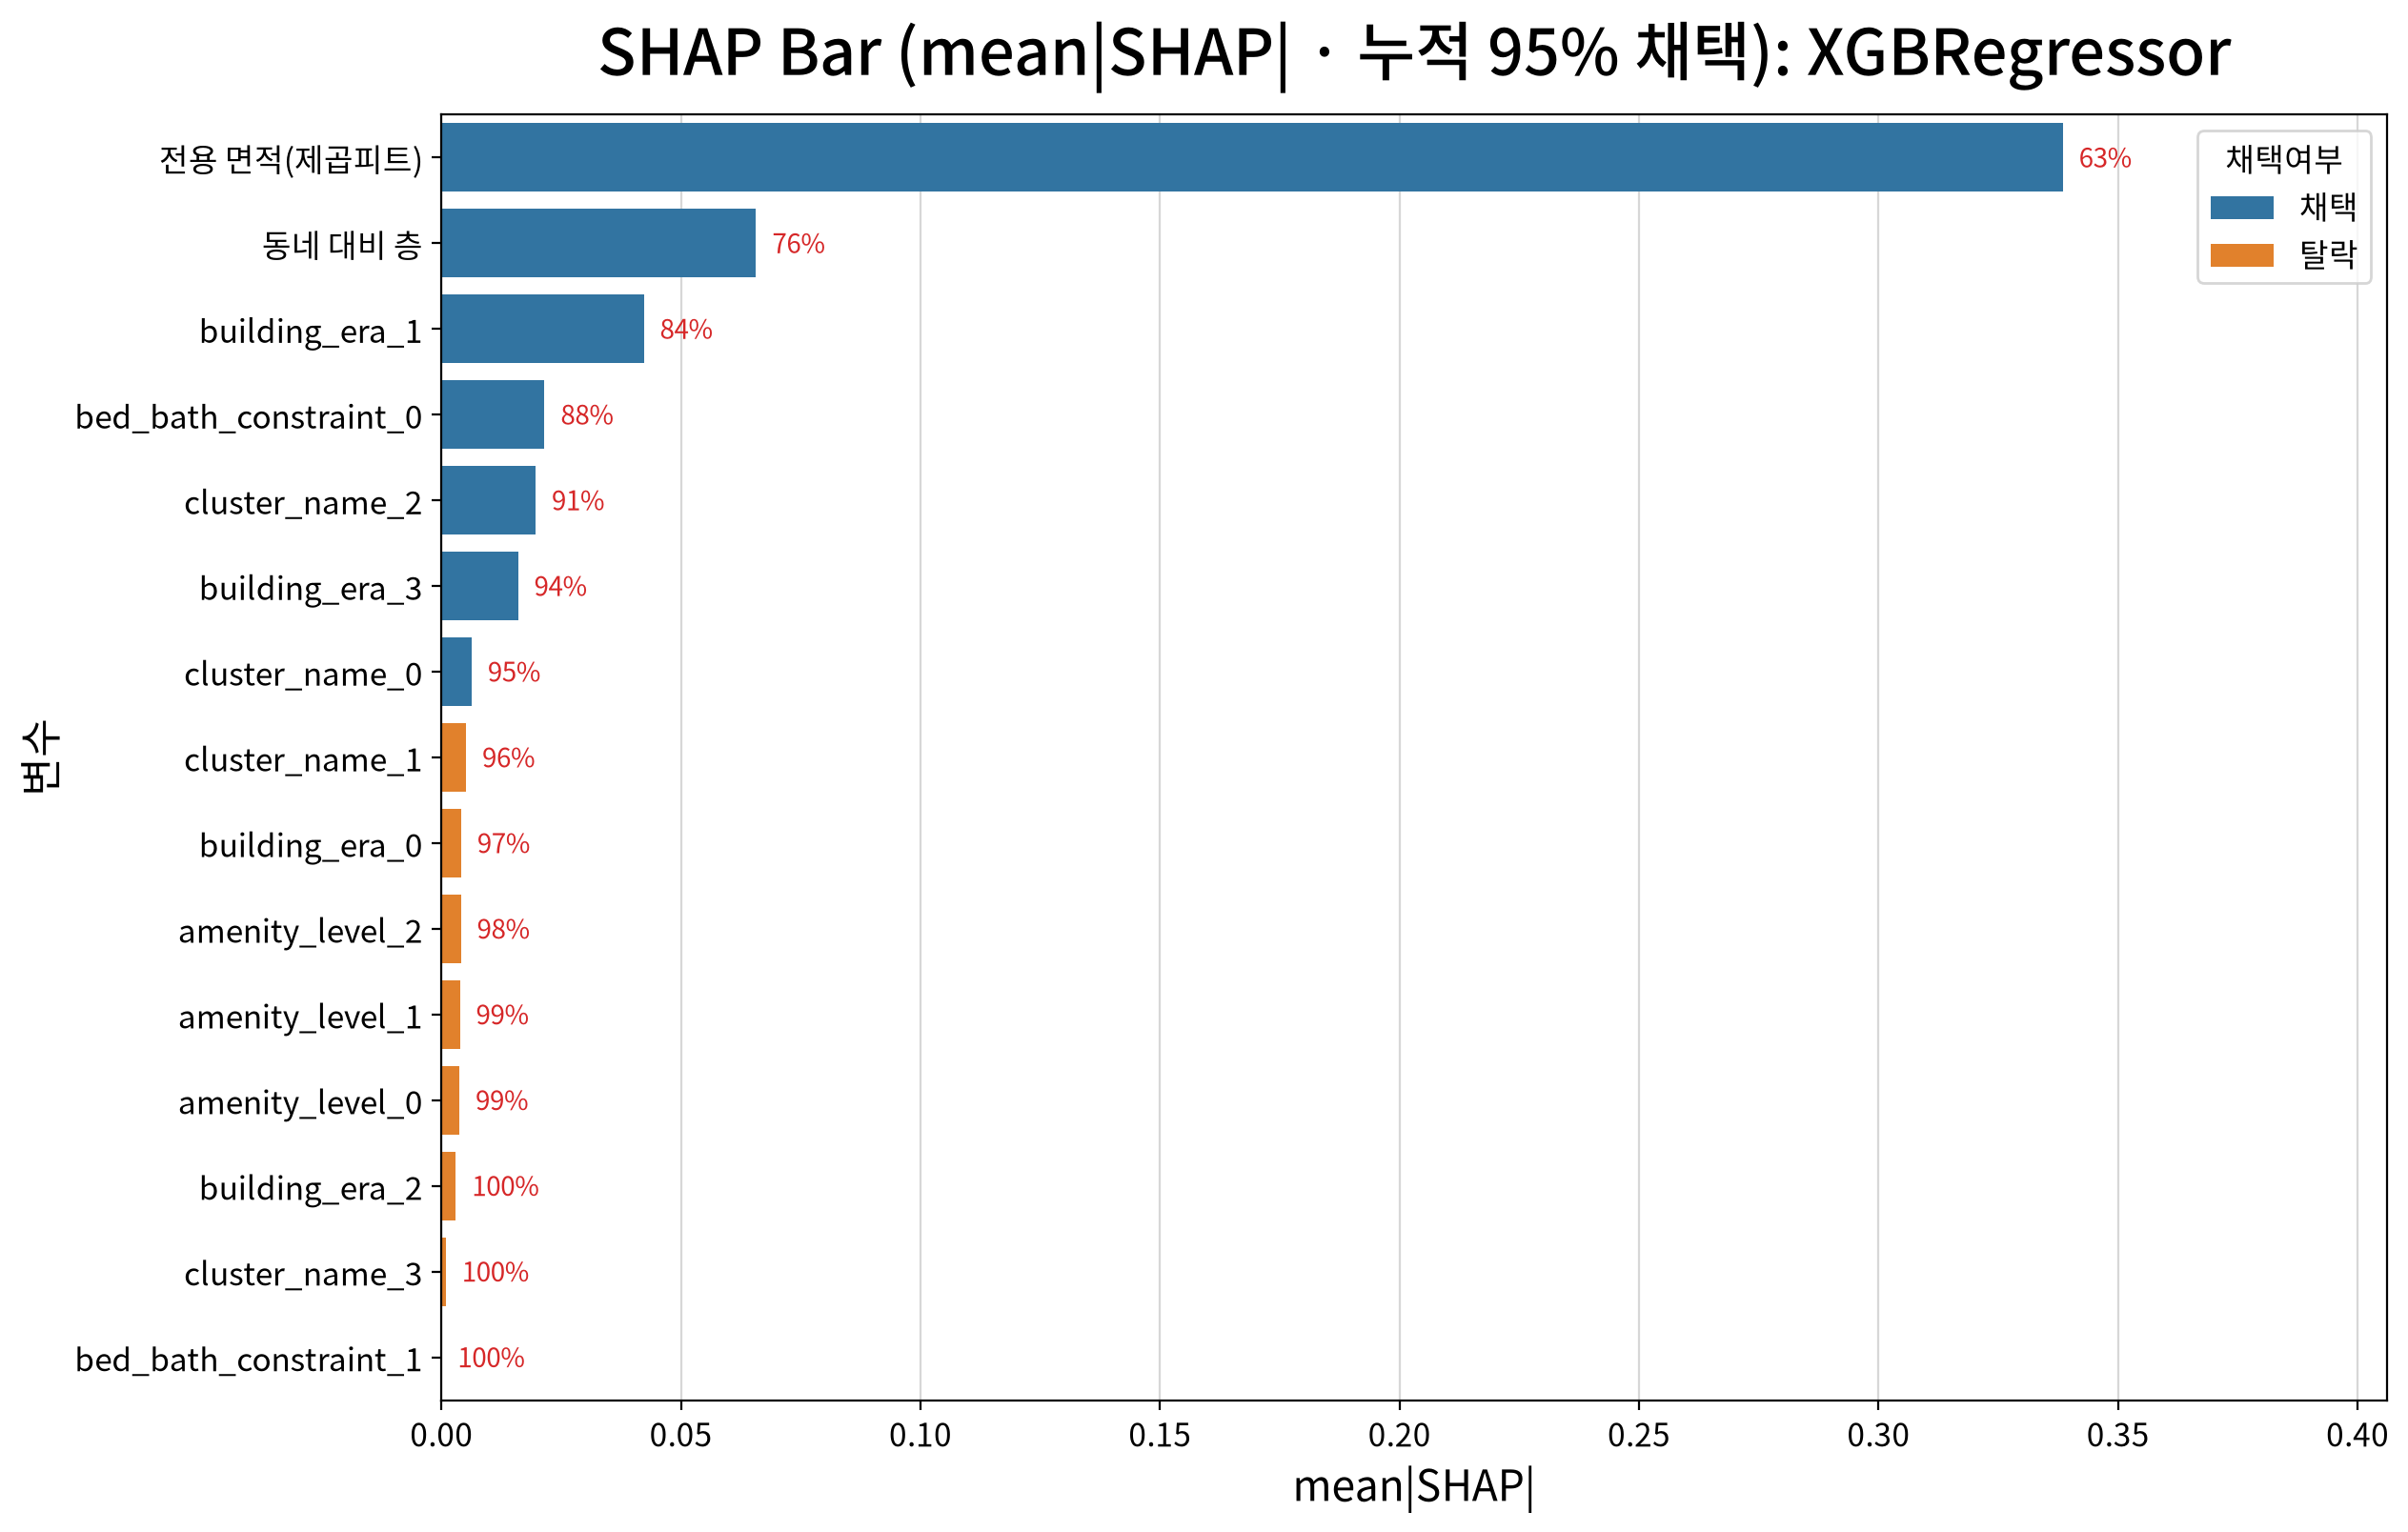

In [26]:
bar_title = f'SHAP Bar (mean|SHAP| · 누적 {cum_ratio:.0%} 채택): {model_class}'

# y축에 적을 이름 - 사전에 있으면 실제 의미로, 없으면 변수명 그대로
plot_df['의미'] = plot_df['Feature'].map(column_means).fillna(plot_df['Feature'])

# 높이 = 여백(140) + 제목(80) + 변수당 40
fig, ax = my_plot.init(title=bar_title, width=1280, height=220 + 40 * len(summary),
                       xlabel='mean|SHAP|', ylabel='변수')

my_plot.barplot(data=plot_df, x='mean_abs_shap', y='의미', hue='채택여부', ax=ax)

vmax = float(plot_df['mean_abs_shap'].max())
ax.set_xlim(0, vmax * 1.20)          # 누적 비율 글자가 들어갈 여백

for i in range(len(summary)):        # 막대마다 누적 비율을 적는다
    value = float(plot_df['mean_abs_shap'].iloc[i])
    cum_text = f"{plot_df['cum_ratio'].iloc[i]:.0%}"
    ax.text(value + vmax * 0.01, i, cum_text, va='center', ha='left',
            fontsize=10, color='tab:red')

my_plot.show()

# 03. 기여의 방향과 분포 시각화
## 1. Summary Plot(Beeswarm Plot)

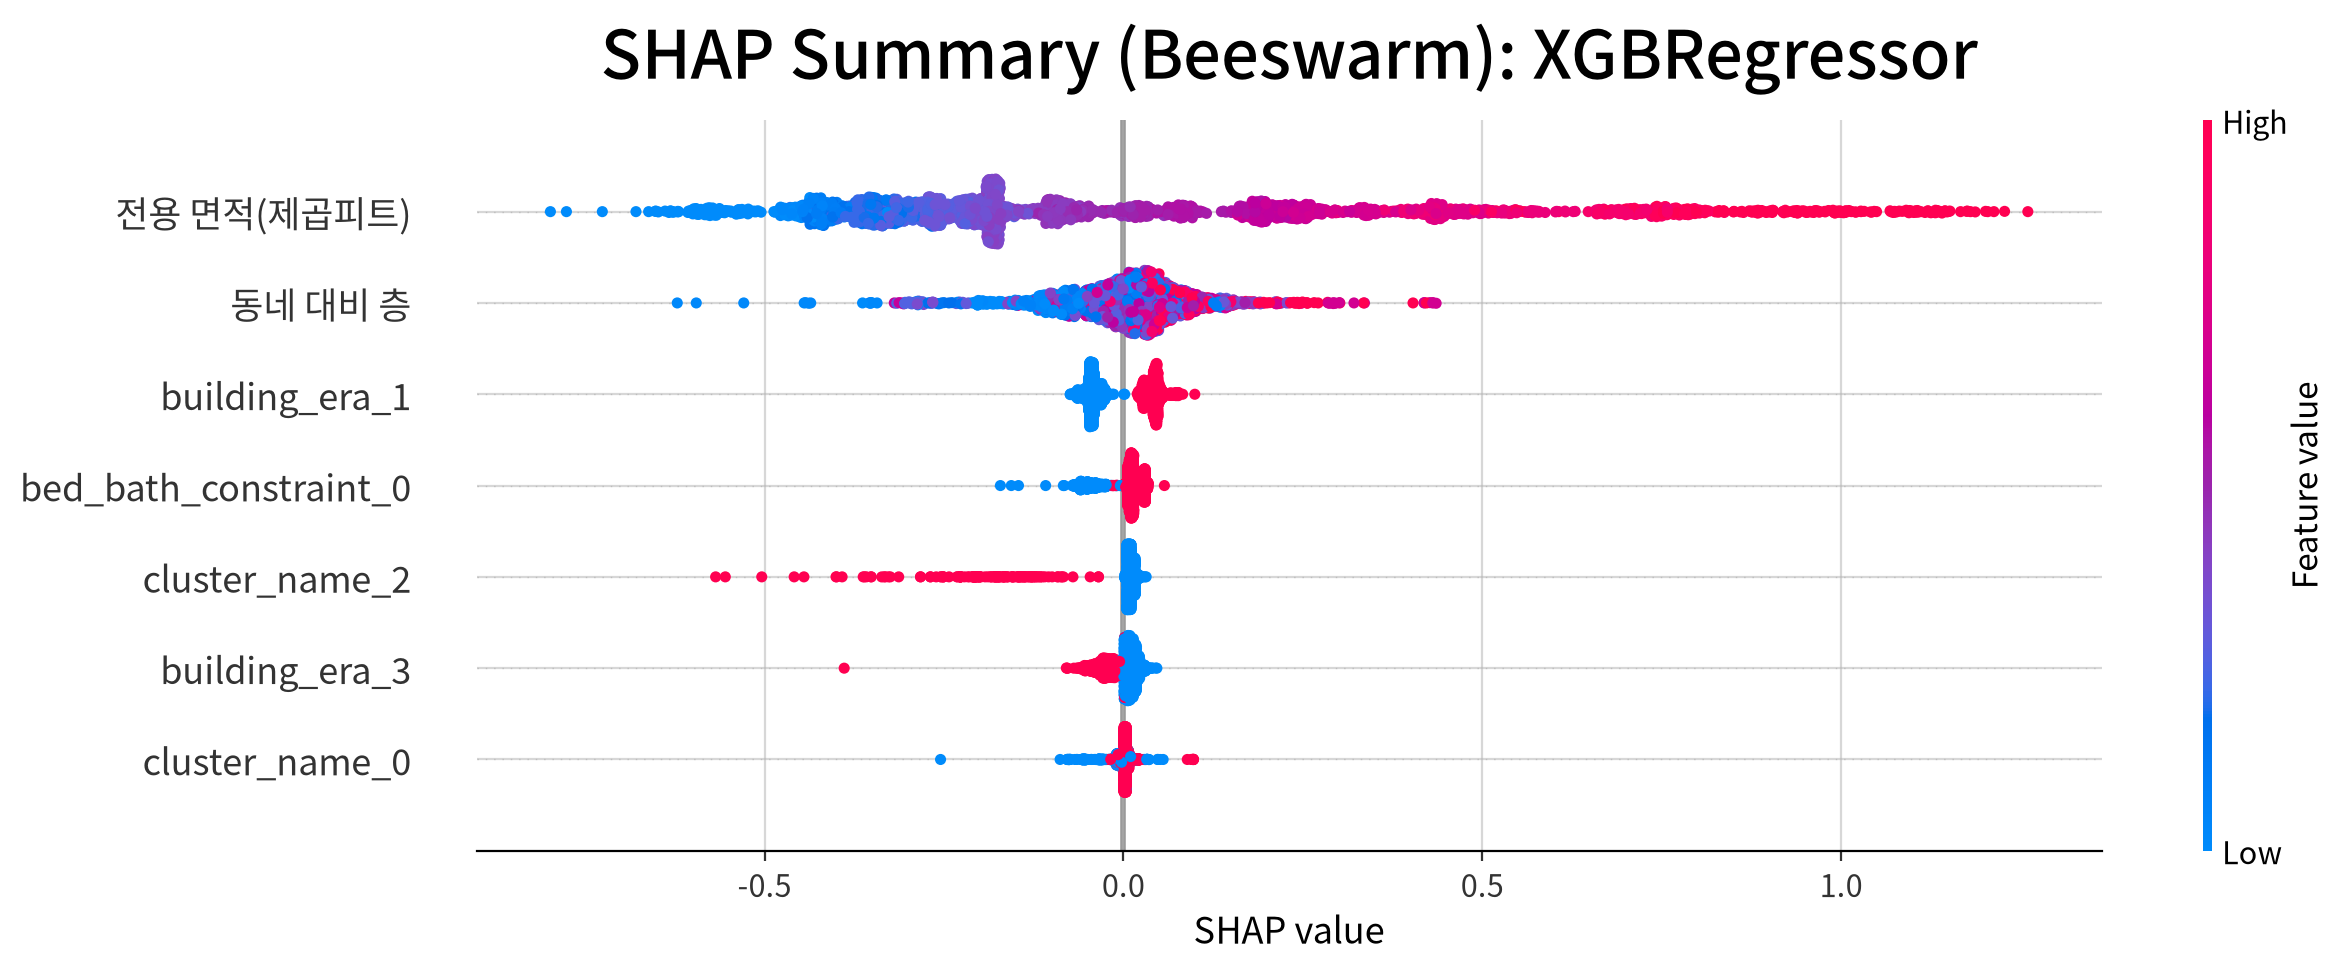

In [27]:
shap_2d = summary.attrs['shap_values']                  # (n, f) 기여도 배열
bee_title = f'SHAP Summary (Beeswarm): {model_class}'   # 그래프 제목

# shap 은 열 이름을 그대로 줄 이름으로 쓴다 - 실제 의미로 바꿔서 넘긴다
bee_df = x_df.rename(columns=column_means)

# 높이 = 여백·축(140) + 제목(80) + 변수당 40 - 막대그래프와 같은 기준
my_plot.init(title=bee_title, width=1280, height=220 + 40 * k)

shap.summary_plot(shap_2d, bee_df, max_display=k,
                  # pyplot이 제어할 수 있도록 shap의 그래프 출력 기능과 크기 조절을 Off한다.
                  show=False, plot_size=None)

plt.xlabel('SHAP value')    # shap 이 붙인 라벨을 덮어쓴다

my_plot.show()

# 04. 변수값과 기여의 관계 시각화
## 1. 주변수 고르기

In [28]:
# 막대그래프에서 '채택' 색이 붙은 변수들
main_features = list(summary.index[:k])

print(f'주변수: {len(main_features)}개 (누적 {cum_ratio:.0%} 기준)')
main_features

주변수: 7개 (누적 95% 기준)


['size_sqft',
 'relative_floor',
 'building_era_1',
 'bed_bath_constraint_0',
 'cluster_name_2',
 'building_era_3',
 'cluster_name_0']

## 2. 상호작용 짝 찾기

In [29]:
partners = []                               # 상호작용 짝을 저장할 리스트

for f in main_features:                     # 주변수마다
    fi = x_df.columns.get_loc(f)            # 변수명의 열 인덱스 찾기
    # 상호작용이 큰 순서
    inter = shap.utils.approximate_interactions(fi, shap_2d, x_df)
    print(f'[{f}] 상호작용이 큰 순서: {inter}')
    # 0번째 항목 = 가장 강한 짝
    partners.append((f, x_df.columns[inter[0]]))

print(f'상호작용 짝: {len(partners)}개')
print(partners)     # 상호작용 짝을 확인한다.

[size_sqft] 상호작용이 큰 순서: [ 8  6  5  7  3  2  1 12 11 10 13 14  9  4  0]
[relative_floor] 상호작용이 큰 순서: [ 6  7  5  0  3  8  2 10 12 13 14 11  9  4  1]
[building_era_1] 상호작용이 큰 순서: [ 8 12 11  0  1  6 13 14 10  7  5  2  9  4  3]
[bed_bath_constraint_0] 상호작용이 큰 순서: [ 0  7  8  3  6  5  2 12 11 10  9  1  4 14 13]
[cluster_name_2] 상호작용이 큰 순서: [ 5  3  0  7 12 11  6  1  9 10 14 13  2  4  8]
[building_era_3] 상호작용이 큰 순서: [12  1 11 13 14  8  0  6 10  7  3  2  9  4  5]
[cluster_name_0] 상호작용이 큰 순서: [ 1  5  3  2  0 14 13 12 11  4 10  7  8  9  6]
상호작용 짝: 7개
[('size_sqft', 'cluster_name_2'), ('relative_floor', 'cluster_name_0'), ('building_era_1', 'cluster_name_2'), ('bed_bath_constraint_0', 'size_sqft'), ('cluster_name_2', 'building_era_3'), ('building_era_3', 'amenity_level_2'), ('cluster_name_0', 'relative_floor')]


## 3. Dependence Plot(1) - 하나의 변수만 시각화 하기

In [30]:
f, partner = partners[0]            # 영향력 1위 변수와 그 변수의 가장 강한 상호작용 짝

fig, ax = my_plot.init(title=f'{column_means[f]}    x   {column_means[partner]}')

# ax를 직접 지정하여 시각화 하면서 show=False 로 지정하면,
# pyplot이 제어할 수 있도록 shap의 그래프 출력 기능과 크기 조절을 OFF한다.
shap.dependence_plot(f, shap_2d, x_df, interaction_index=partner, ax=ax, show=False)

# (0,0)을 지나는 가로 직선
ax.axhline(0, color='#990000', linestyle=':', linewidth=2)

my_plot.show()

KeyError: 'cluster_name_2'